# 🛍️ NeuralRetail — Exploratory Data Analysis (EDA)
## Amdox Technologies | Data Science & Analytics
---
### What this notebook does:
- Loads and inspects the Online Retail dataset
- Cleans and preprocesses the data
- Analyzes sales trends, top products, top countries
- Creates visualizations for business insights
- Saves clean data for model training

In [1]:
# ============================================================
# CELL 2: Import all required libraries
# ============================================================

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# System
import warnings
import os

# Settings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")
print(f"📦 Pandas version: {pd.__version__}")
print(f"📦 Numpy version: {np.__version__}")

✅ All libraries imported successfully!
📦 Pandas version: 2.2.2
📦 Numpy version: 1.26.4


In [2]:
# ============================================================
# CELL 3: Load the dataset
# ============================================================

# Define path to dataset
DATA_PATH = '../data/Online_Retail.xlsx'

# Load the Excel file
print("📂 Loading dataset... (this may take 30-60 seconds for Excel files)")
df_raw = pd.read_excel(DATA_PATH, engine='openpyxl')

# Save a copy of raw data — we never modify the original
df = df_raw.copy()

print(f"✅ Dataset loaded successfully!")
print(f"📊 Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

📂 Loading dataset... (this may take 30-60 seconds for Excel files)
✅ Dataset loaded successfully!
📊 Shape: 541,909 rows × 8 columns


In [3]:
# ============================================================
# CELL 4: First look at the data
# ============================================================

print("=" * 60)
print("FIRST 5 ROWS OF DATA")
print("=" * 60)
display(df.head())

print("\n" + "=" * 60)
print("DATASET INFO — Column names, data types, null counts")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("BASIC STATISTICS")
print("=" * 60)
display(df.describe())

FIRST 5 ROWS OF DATA


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.00,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.00,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom



DATASET INFO — Column names, data types, null counts
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB

BASIC STATISTICS


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.00,541909,541909.00,406829.00
mean,9.55,2011-07-04 13:34:57.156386048,4.61,15287.69
min,-80995.00,2010-12-01 08:26:00,-11062.06,12346.00
25%,1.00,2011-03-28 11:34:00,1.25,13953.00
50%,3.00,2011-07-19 17:17:00,2.08,15152.00
75%,10.00,2011-10-19 11:27:00,4.13,16791.00
max,80995.00,2011-12-09 12:50:00,38970.00,18287.00
std,218.08,NaN,96.76,1713.60


MISSING VALUES ANALYSIS
             Missing Count  Missing %
Description           1454       0.27
CustomerID          135080      24.93


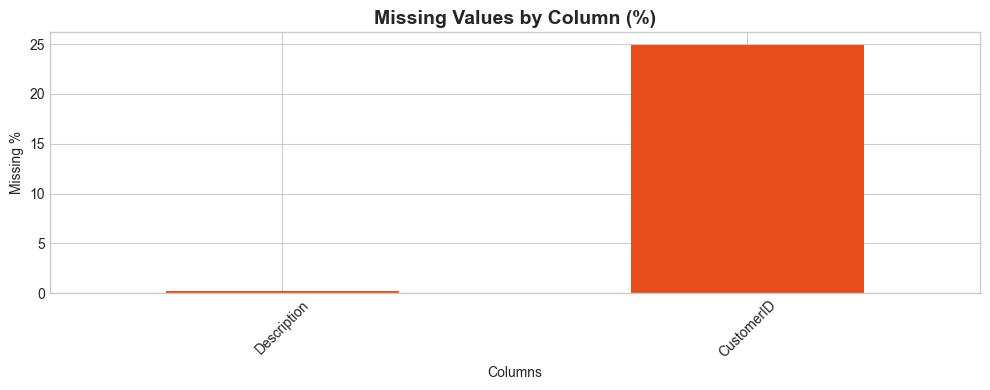

✅ Missing values chart saved!


In [4]:
# ============================================================
# CELL 5: Missing values analysis
# ============================================================

print("=" * 60)
print("MISSING VALUES ANALYSIS")
print("=" * 60)

# Count missing values per column
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
})

# Only show columns with missing values
missing = missing[missing['Missing Count'] > 0]
print(missing)

# Visualize missing values
fig, ax = plt.subplots(figsize=(10, 4))
missing['Missing %'].plot(kind='bar', color='#E84E1B', ax=ax)
ax.set_title('Missing Values by Column (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Columns')
ax.set_ylabel('Missing %')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
plt.tight_layout()
plt.savefig('../evidently_reports/missing_values.png', dpi=150)
plt.show()
print("✅ Missing values chart saved!")

In [5]:
# ============================================================
# CELL 6: Data Cleaning
# ============================================================

print("🧹 Starting data cleaning...")
print(f"Original shape: {df.shape}")

# Step 1: Remove rows where CustomerID is missing
# (we can't do customer analysis without customer ID)
df = df.dropna(subset=['CustomerID'])
print(f"After removing missing CustomerID: {df.shape}")

# Step 2: Remove cancelled transactions
# (InvoiceNo starting with 'C' means cancellation)
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
print(f"After removing cancellations: {df.shape}")

# Step 3: Remove rows with negative or zero Quantity
# (can't have negative items sold)
df = df[df['Quantity'] > 0]
print(f"After removing negative quantity: {df.shape}")

# Step 4: Remove rows with negative or zero UnitPrice
df = df[df['UnitPrice'] > 0]
print(f"After removing negative price: {df.shape}")

# Step 5: Remove duplicate rows
df = df.drop_duplicates()
print(f"After removing duplicates: {df.shape}")

# Step 6: Fix data types
df['CustomerID'] = df['CustomerID'].astype(int).astype(str)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['InvoiceNo'] = df['InvoiceNo'].astype(str)

# Step 7: Create useful new columns
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']  # Revenue per row
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['DayOfWeek'] = df['InvoiceDate'].dt.dayofweek  # 0=Monday, 6=Sunday
df['Hour'] = df['InvoiceDate'].dt.hour
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

print(f"\n✅ Data cleaning complete!")
print(f"Final shape: {df.shape}")
print(f"\nNew columns added: TotalPrice, Year, Month, Day, DayOfWeek, Hour, YearMonth")

🧹 Starting data cleaning...
Original shape: (541909, 8)
After removing missing CustomerID: (406829, 8)
After removing cancellations: (397924, 8)
After removing negative quantity: (397924, 8)
After removing negative price: (397884, 8)
After removing duplicates: (392692, 8)

✅ Data cleaning complete!
Final shape: (392692, 15)

New columns added: TotalPrice, Year, Month, Day, DayOfWeek, Hour, YearMonth


In [6]:
# ============================================================
# CELL 7: Overall Business KPIs
# ============================================================

print("=" * 60)
print("📊 BUSINESS KPIs — KEY PERFORMANCE INDICATORS")
print("=" * 60)

total_revenue    = df['TotalPrice'].sum()
total_orders     = df['InvoiceNo'].nunique()
total_customers  = df['CustomerID'].nunique()
total_products   = df['StockCode'].nunique()
avg_order_value  = total_revenue / total_orders
date_range_start = df['InvoiceDate'].min().strftime('%Y-%m-%d')
date_range_end   = df['InvoiceDate'].max().strftime('%Y-%m-%d')

print(f"💰 Total Revenue        : £{total_revenue:>15,.2f}")
print(f"🛒 Total Orders         : {total_orders:>15,}")
print(f"👥 Unique Customers     : {total_customers:>15,}")
print(f"📦 Unique Products      : {total_products:>15,}")
print(f"💳 Avg Order Value      : £{avg_order_value:>15,.2f}")
print(f"📅 Date Range           : {date_range_start} → {date_range_end}")

📊 BUSINESS KPIs — KEY PERFORMANCE INDICATORS
💰 Total Revenue        : £   8,887,208.89
🛒 Total Orders         :          18,532
👥 Unique Customers     :           4,338
📦 Unique Products      :           3,665
💳 Avg Order Value      : £         479.56
📅 Date Range           : 2010-12-01 → 2011-12-09


In [7]:
# ============================================================
# CELL 8: Monthly Revenue Trend
# ============================================================

# Group by YearMonth and sum revenue
monthly_revenue = df.groupby('YearMonth')['TotalPrice'].sum().reset_index()
monthly_revenue['YearMonth_str'] = monthly_revenue['YearMonth'].astype(str)

# Plot
fig = px.line(
    monthly_revenue,
    x='YearMonth_str',
    y='TotalPrice',
    title='📈 Monthly Revenue Trend',
    labels={'TotalPrice': 'Revenue (£)', 'YearMonth_str': 'Month'},
    markers=True,
    color_discrete_sequence=['#E84E1B']
)
fig.update_layout(
    title_font_size=18,
    xaxis_tickangle=-45,
    hovermode='x unified',
    plot_bgcolor='white',
    paper_bgcolor='white'
)
fig.show()
print("✅ Monthly revenue trend plotted!")

✅ Monthly revenue trend plotted!


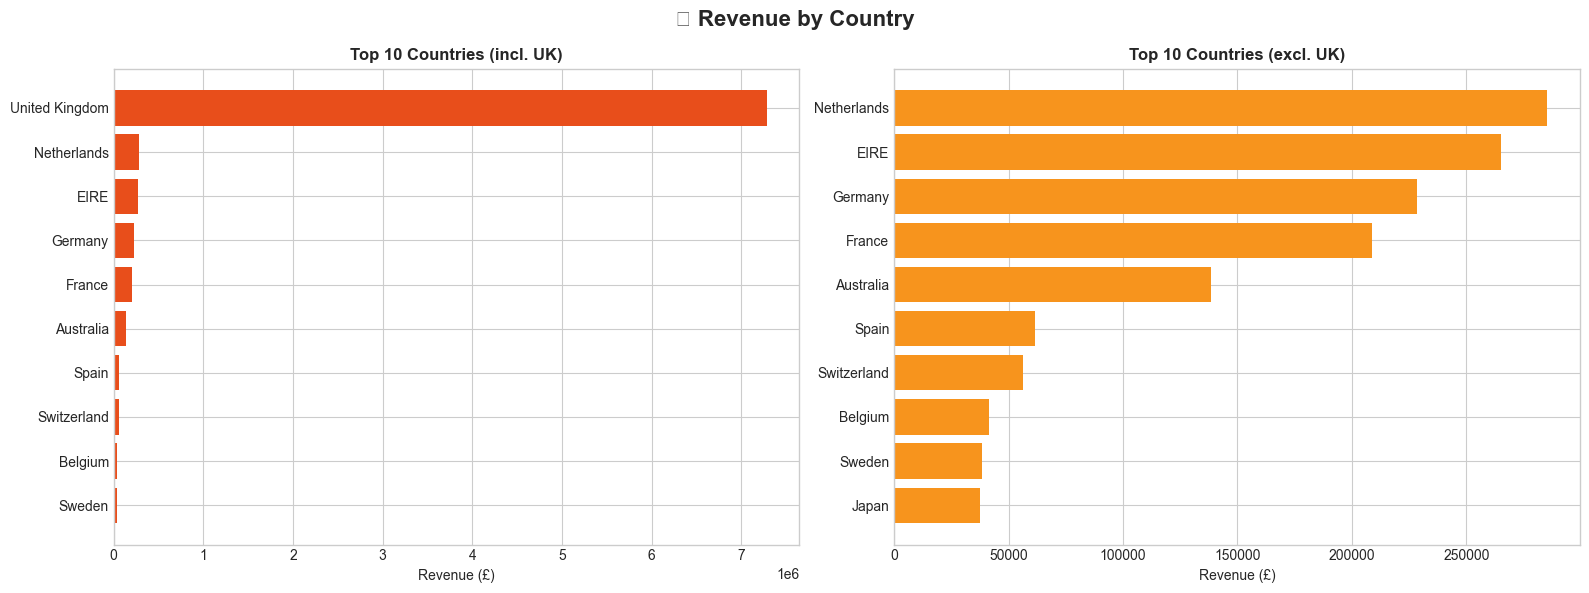

✅ Country revenue chart saved!


In [8]:
# ============================================================
# CELL 9: Top 10 Countries by Revenue
# ============================================================

# Group by country
country_revenue = df.groupby('Country')['TotalPrice'].sum().reset_index()
country_revenue = country_revenue.sort_values('TotalPrice', ascending=False)

# Exclude UK as it dominates — show rest separately
uk_revenue = country_revenue[country_revenue['Country'] == 'United Kingdom']
top10_ex_uk = country_revenue[country_revenue['Country'] != 'United Kingdom'].head(10)

# Plot top 10 excluding UK
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left — all countries including UK
axes[0].barh(
    country_revenue.head(10)['Country'],
    country_revenue.head(10)['TotalPrice'],
    color='#E84E1B'
)
axes[0].set_title('Top 10 Countries (incl. UK)', fontweight='bold')
axes[0].set_xlabel('Revenue (£)')
axes[0].invert_yaxis()

# Right — excluding UK to see others clearly
axes[1].barh(
    top10_ex_uk['Country'],
    top10_ex_uk['TotalPrice'],
    color='#F7941D'
)
axes[1].set_title('Top 10 Countries (excl. UK)', fontweight='bold')
axes[1].set_xlabel('Revenue (£)')
axes[1].invert_yaxis()

plt.suptitle('🌍 Revenue by Country', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../evidently_reports/top_countries.png', dpi=150)
plt.show()
print("✅ Country revenue chart saved!")

In [9]:
# ============================================================
# CELL 10: Top 10 Products by Revenue
# ============================================================

# Group by product description
product_revenue = df.groupby('Description')['TotalPrice'].sum().reset_index()
product_revenue = product_revenue.sort_values('TotalPrice', ascending=False).head(10)

# Plot
fig = px.bar(
    product_revenue,
    x='TotalPrice',
    y='Description',
    orientation='h',
    title='🏆 Top 10 Products by Revenue',
    labels={'TotalPrice': 'Revenue (£)', 'Description': 'Product'},
    color='TotalPrice',
    color_continuous_scale=['#FBBA13', '#F7941D', '#E84E1B']
)
fig.update_layout(
    title_font_size=18,
    yaxis={'categoryorder': 'total ascending'},
    plot_bgcolor='white',
    paper_bgcolor='white',
    showlegend=False
)
fig.show()
print("✅ Top products chart plotted!")

✅ Top products chart plotted!


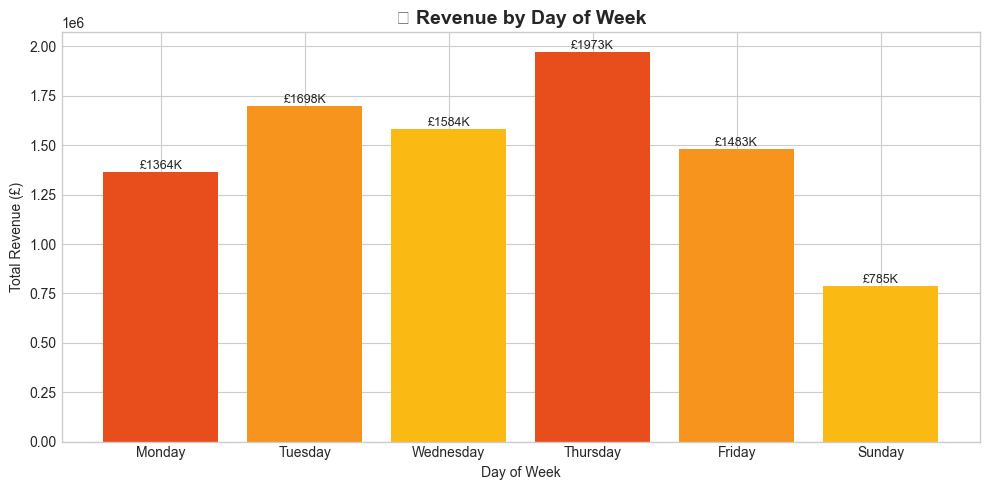

✅ Day of week chart saved!


In [10]:
# ============================================================
# CELL 11: Sales by Day of Week
# ============================================================

# Map day numbers to names
day_names = {0:'Monday', 1:'Tuesday', 2:'Wednesday',
             3:'Thursday', 4:'Friday', 5:'Saturday', 6:'Sunday'}

dow_revenue = df.groupby('DayOfWeek')['TotalPrice'].sum().reset_index()
dow_revenue['DayName'] = dow_revenue['DayOfWeek'].map(day_names)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    dow_revenue['DayName'],
    dow_revenue['TotalPrice'],
    color=['#E84E1B', '#F7941D', '#FBBA13', '#E84E1B', '#F7941D', '#FBBA13', '#E84E1B']
)
ax.set_title('📅 Revenue by Day of Week', fontsize=14, fontweight='bold')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Total Revenue (£)')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'£{height/1000:.0f}K', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../evidently_reports/sales_by_day.png', dpi=150)
plt.show()
print("✅ Day of week chart saved!")

In [11]:
# ============================================================
# CELL 12: Save cleaned data for next topics
# ============================================================

# Save as CSV for fast loading in future notebooks
clean_data_path = '../data/online_retail_clean.csv'
df.to_csv(clean_data_path, index=False)

print(f"✅ Clean data saved to: {clean_data_path}")
print(f"📊 Final dataset shape: {df.shape}")
print(f"\n📋 Columns in clean dataset:")
for col in df.columns:
    print(f"   → {col}")

✅ Clean data saved to: ../data/online_retail_clean.csv
📊 Final dataset shape: (392692, 15)

📋 Columns in clean dataset:
   → InvoiceNo
   → StockCode
   → Description
   → Quantity
   → InvoiceDate
   → UnitPrice
   → CustomerID
   → Country
   → TotalPrice
   → Year
   → Month
   → Day
   → DayOfWeek
   → Hour
   → YearMonth


## ✅ EDA Complete — Summary

### What we found:
- Dataset contains transactional retail data from a UK-based online store
- After cleaning: removed nulls, cancellations, negative values, duplicates
- Created new features: TotalPrice, Year, Month, DayOfWeek, Hour
- **United Kingdom** dominates revenue
- Clear **monthly seasonality** with peak in November (holiday season)
- Top products are gift/home decor items

### Clean data saved to:
`data/online_retail_clean.csv` — ready for Feature Engineering